# 👁️ Ghost-Vision — NTU RGB+D 60 Training (Improved)
**MSc Data Science | VIT AP | Krify Technologies**

### Improvements over NTU120 run:
- NTU60 has cleaner class separation → higher accuracy expected
- 5-block ST-GCN instead of 9 → less overfitting on our dataset size
- No label smoothing → model converges properly
- Full data + sqrt weighted sampler → balanced without losing samples

### Steps:
1. Check GPU
2. Download NTU60 dataset
3. Write all code files
4. Train ST-GCN
5. Train Severity CNN
6. Train PreFall LSTM
7. Download models

## Step 1 — Check GPU

In [ ]:
import torch
print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
else:
    print('WARNING: Go to Runtime > Change runtime type > T4 GPU')

PyTorch : 2.10.0+cu128
CUDA    : True
GPU     : Tesla T4
VRAM    : 15.6 GB


## Step 2 — Download NTU60 Dataset

In [ ]:
import urllib.request
import os

PKL_PATH = '/content/ntu60_3d.pkl'

if os.path.exists(PKL_PATH):
    size = os.path.getsize(PKL_PATH) / 1e9
    print(f'NTU60 already exists! Size: {size:.2f} GB')
else:
    print('Downloading NTU60 (this takes 3-5 minutes)...')
    url = 'https://download.openmmlab.com/mmaction/v1.0/skeleton/data/ntu60_3d.pkl'
    urllib.request.urlretrieve(url, PKL_PATH)
    size = os.path.getsize(PKL_PATH) / 1e9
    print(f'Downloaded! Size: {size:.2f} GB')

Downloaded! Size: 1.19 GB


In [ ]:
# Verify dataset structure
import pickle
import numpy as np

with open(PKL_PATH, 'rb') as f:
    data = pickle.load(f)

print('Keys          :', list(data.keys()))
print('Split keys    :', list(data['split'].keys()))
print('Annotations   :', len(data['annotations']))
print('Max label     :', max(a['label'] for a in data['annotations']))
print('Keypoint shape:', np.array(data['annotations'][0]['keypoint']).shape)
print()
print('Expected: max label=59 (NTU60), keypoint shape=(1, T, 25, 3)')

Keys          : ['split', 'annotations']
Split keys    : ['xsub_train', 'xsub_val', 'xset_train', 'xset_val', 'xview_train', 'xview_val']
Annotations   : 56578
Max label     : 59
Keypoint shape: (1, 103, 25, 3)

Expected: max label=59 (NTU60), keypoint shape=(1, T, 25, 3)


## Step 3 — Write All Code Files

In [ ]:
# Write config.py
config_code = '''
ACTIONS = {
    0: "Normal",
    1: "Fall",
    2: "Pre-Fall Risk",
    3: "Motionless",
    4: "Sit Down",
}
DANGEROUS_ACTIONS    = [1, 2, 3]
CONFIDENCE_THRESHOLD = 0.85
NUM_JOINTS           = 25
SEQUENCE_LENGTH      = 30
'''
with open('/content/config.py', 'w') as f:
    f.write(config_code)
print('config.py written')

config.py written


In [ ]:
# Write models.py — 5-block ST-GCN (better for our dataset size)
models_code = '''
import torch
import torch.nn as nn

class GraphConvolution(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(GraphConvolution, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=(1,1))
    def forward(self, x, A):
        x = torch.einsum("bctv,vw->bctw", x, A)
        return self.conv(x)

class STGCNBlock(nn.Module):
    def __init__(self, in_channels, out_channels,
                 temporal_kernel=9, stride=1, dropout=0.5):
        super(STGCNBlock, self).__init__()
        self.gcn = GraphConvolution(in_channels, out_channels)
        padding  = ((temporal_kernel - 1) // 2, 0)
        self.tcn = nn.Sequential(
            nn.BatchNorm2d(out_channels), nn.ReLU(),
            nn.Conv2d(out_channels, out_channels,
                      kernel_size=(temporal_kernel,1),
                      stride=(stride,1), padding=padding),
            nn.BatchNorm2d(out_channels), nn.Dropout(dropout)
        )
        if in_channels != out_channels or stride != 1:
            self.residual = nn.Sequential(
                nn.Conv2d(in_channels, out_channels,
                          kernel_size=1, stride=(stride,1)),
                nn.BatchNorm2d(out_channels)
            )
        else:
            self.residual = nn.Identity()
        self.relu = nn.ReLU()

    def forward(self, x, A):
        res = self.residual(x)
        x   = self.gcn(x, A)
        x   = self.tcn(x)
        return self.relu(x + res)

class STGCN(nn.Module):
    """5-block ST-GCN — optimal for dataset size of 10k-30k sequences"""
    def __init__(self, num_joints=25, num_classes=5, in_channels=3):
        super(STGCN, self).__init__()
        self.data_bn = nn.BatchNorm1d(in_channels * num_joints)
        self.st_gcn_blocks = nn.ModuleList([
            STGCNBlock(in_channels, 64),
            STGCNBlock(64,          64),
            STGCNBlock(64,          128),
            STGCNBlock(128,         128),
            STGCNBlock(128,         256),
        ])
        self.gap = nn.AdaptiveAvgPool2d((1,1))
        self.fc  = nn.Linear(256, num_classes)

    def forward(self, x, A):
        B, C, T, V = x.shape
        x_bn = x.permute(0,3,1,2).contiguous().view(B, V*C, T)
        x_bn = self.data_bn(x_bn)
        x    = x_bn.view(B, V, C, T).permute(0,2,3,1)
        for block in self.st_gcn_blocks:
            x = block(x, A)
        x = self.gap(x).view(B, -1)
        return self.fc(x)

class FallSeverityCNN(nn.Module):
    def __init__(self, num_joints=25, sequence_length=30):
        super(FallSeverityCNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=(3,3), padding=1),
            nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2,2),
            nn.Conv2d(32, 64, kernel_size=(3,3), padding=1),
            nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2,2),
            nn.Conv2d(64, 128, kernel_size=(3,3), padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.AdaptiveAvgPool2d((2,2))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*2*2, 256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, 64), nn.ReLU(),
            nn.Linear(64, 3)
        )
    def forward(self, x): return self.classifier(self.conv_layers(x))

class PreFallLSTM(nn.Module):
    def __init__(self, input_size=75, hidden_size=128, num_layers=2):
        super(PreFallLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            batch_first=True, dropout=0.3,
                            bidirectional=False)
        self.attention = nn.Sequential(
            nn.Linear(hidden_size, 64), nn.Tanh(),
            nn.Linear(64, 1), nn.Softmax(dim=1)
        )
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 64), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 1), nn.Sigmoid()
        )
    def forward(self, x):
        out, _ = self.lstm(x)
        attn   = self.attention(out)
        ctx    = torch.sum(attn * out, dim=1)
        return self.classifier(ctx)
'''
with open('/content/models.py', 'w') as f:
    f.write(models_code)

import importlib
try:
    import models
    importlib.reload(models)
except:
    import models
from models import STGCN, FallSeverityCNN, PreFallLSTM
print('models.py written — 5-block ST-GCN loaded!')

models.py written — 5-block ST-GCN loaded!


In [ ]:
# Write ntu_loader.py — NTU60 clean mapping
ntu_loader_code = '''
import pickle
import numpy as np
from torch.utils.data import Dataset
import torch
from collections import Counter

NUM_NTU_JOINTS = 25

# NTU60 mapping — clean, minimal overlap between classes
NTU_TO_GHOSTVISION = {
    # Fall (label 1) — only clear fall action
    42: 1,   # A043 — fall down

    # Pre-Fall Risk (label 2) — unstable gait actions
    39: 2,   # A040 — staggering
    44: 2,   # A045 — feeling dizzy

    # Motionless (label 3) — stationary distress
    40: 3,   # A041 — headache
    41: 3,   # A042 — chest pain

    # Sit Down (label 4)
    26: 4,   # A027 — sit down

    # Normal (label 0) — common daily activities
    0:  0,   # A001 — drink water
    1:  0,   # A002 — eat meal
    2:  0,   # A003 — brushing teeth
    7:  0,   # A008 — stand up
    8:  0,   # A009 — clapping
    9:  0,   # A010 — reading
    10: 0,   # A011 — writing
    11: 0,   # A012 — tear up paper
    22: 0,   # A023 — hand waving
    23: 0,   # A024 — kicking something
    27: 0,   # A028 — stand up variant
}

NTU_CONNECTIONS = [
    (0,1),(1,20),(20,2),(2,3),
    (20,4),(4,5),(5,6),(6,7),
    (20,8),(8,9),(9,10),(10,11),
    (0,16),(16,17),(17,18),(18,19),
    (0,12),(12,13),(13,14),(14,15),
    (2,24),(24,22),(22,23),(2,21),
]

class NTUDataset(Dataset):
    def __init__(self, pkl_path, split="xsub_train",
                 sequence_length=30, augment=False):
        self.sequence_length = sequence_length
        self.augment = augment
        print(f"Loading NTU RGB+D 60 from {pkl_path} ...")
        with open(pkl_path, "rb") as f:
            raw = pickle.load(f)
        split_ids = set(raw["split"][split])
        self.samples = []
        skipped = 0
        for ann in raw["annotations"]:
            if ann["frame_dir"] not in split_ids:
                continue
            ntu_label = ann["label"]
            if ntu_label not in NTU_TO_GHOSTVISION:
                skipped += 1
                continue
            gv_label = NTU_TO_GHOSTVISION[ntu_label]
            kp = ann["keypoint"][0]
            self.samples.append((kp, gv_label))
        label_counts = Counter(s[1] for s in self.samples)
        class_names  = ["Normal","Fall","Pre-Fall Risk",
                        "Motionless","Sit Down"]
        print(f"Loaded {len(self.samples)} | Skipped {skipped}")
        for i, name in enumerate(class_names):
            print(f"  {name}: {label_counts.get(i,0)}")

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        kp, label = self.samples[idx]
        kp = self._pad_or_trim(kp)
        kp = self._normalize(kp)
        if self.augment:
            kp = self._augment(kp)
        tensor = torch.FloatTensor(kp.transpose(2, 0, 1))
        return tensor, label

    def _pad_or_trim(self, kp):
        T = kp.shape[0]
        if T == self.sequence_length: return kp
        elif T < self.sequence_length:
            pad = np.tile(kp[-1:], (self.sequence_length-T, 1, 1))
            return np.concatenate([kp, pad], axis=0)
        else:
            idx = np.linspace(0, T-1, self.sequence_length, dtype=int)
            return kp[idx]

    def _normalize(self, kp):
        kp = kp.copy().astype(np.float32)
        center = kp[:, 0:1, :]
        kp = kp - center
        torso = np.mean(
            np.linalg.norm(kp[:, 2, :] - kp[:, 0, :], axis=1))
        if torso > 1e-6: kp = kp / torso
        return kp

    def _augment(self, kp):
        kp = kp.copy()
        if np.random.random() > 0.5:
            angle = np.random.uniform(-15, 15) * np.pi / 180
            c, s  = np.cos(angle), np.sin(angle)
            R     = np.array([[c,0,s],[0,1,0],[-s,0,c]])
            kp    = kp @ R.T
        if np.random.random() > 0.5: kp[:,:,0] *= -1
        if np.random.random() > 0.5:
            kp += np.random.normal(0, 0.01, kp.shape)
        if np.random.random() > 0.5:
            T     = kp.shape[0]
            start = np.random.randint(0, T//4)
            end   = np.random.randint(3*T//4, T)
            cropped = kp[start:end]
            idx   = np.linspace(0, len(cropped)-1, T, dtype=int)
            kp    = cropped[idx]
        return kp

def build_ntu_adjacency():
    A = np.zeros((NUM_NTU_JOINTS, NUM_NTU_JOINTS))
    for i, j in NTU_CONNECTIONS:
        A[i][j] = 1
        A[j][i] = 1
    A = A + np.eye(NUM_NTU_JOINTS)
    D = np.diag(np.sum(A, axis=1))
    D_inv_sqrt = np.linalg.inv(np.sqrt(D))
    A_norm = D_inv_sqrt @ A @ D_inv_sqrt
    return torch.FloatTensor(A_norm)
'''
with open('/content/ntu_loader.py', 'w') as f:
    f.write(ntu_loader_code)

try:
    import ntu_loader
    importlib.reload(ntu_loader)
except:
    import ntu_loader
from ntu_loader import NTUDataset, build_ntu_adjacency, NUM_NTU_JOINTS
print(f'ntu_loader.py written — mapping has {len(ntu_loader.NTU_TO_GHOSTVISION)} classes')

ntu_loader.py written — mapping has 17 classes


## Step 4 — Train ST-GCN (Fall Detection)
**Key improvements:**
- 5-block model instead of 9
- No label smoothing
- Full data with sqrt weighted sampler
- Expected accuracy: 80-87%

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import os
from torch.utils.data import DataLoader, WeightedRandomSampler
from sklearn.metrics import classification_report, confusion_matrix
from collections import Counter
import matplotlib.pyplot as plt

from ntu_loader import NTUDataset, build_ntu_adjacency, NUM_NTU_JOINTS
from models import STGCN

os.makedirs('/content/saved_models', exist_ok=True)

PKL_PATH    = '/content/ntu60_3d.pkl'
STGCN_PATH  = '/content/saved_models/stgcn_ntu60.pth'
NUM_CLASSES = 5
CLASS_NAMES = ['Normal','Fall','Pre-Fall Risk','Motionless','Sit Down']
EPOCHS      = 80
BATCH_SIZE  = 64
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Training on: {DEVICE}')

# Load full dataset — no subset cap
train_ds = NTUDataset(PKL_PATH, split='xsub_train',
                      sequence_length=30, augment=True)
val_ds   = NTUDataset(PKL_PATH, split='xsub_val',
                      sequence_length=30, augment=False)

# Sqrt weighted sampler — softer balancing than inverse frequency
labels  = [train_ds.samples[i][1] for i in range(len(train_ds))]
counts  = Counter(labels)
weights = [1.0 / (counts[l] ** 0.5) for l in labels]
sampler = WeightedRandomSampler(
    weights, num_samples=len(weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          sampler=sampler, num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2)

print(f'\nTrain batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')

# Fresh 5-block model
torch.manual_seed(42)
np.random.seed(42)
A     = build_ntu_adjacency().to(DEVICE)
model = STGCN(num_joints=NUM_NTU_JOINTS,
              num_classes=NUM_CLASSES).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f'Model params  : {total_params:,}')

# OneCycleLR — best for skeleton data convergence
optimizer = torch.optim.Adam(
    model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr          = 0.01,
    epochs          = EPOCHS,
    steps_per_epoch = len(train_loader),
    pct_start       = 0.2,
    anneal_strategy = 'cos'
)

# No label smoothing — clean CrossEntropy
criterion = nn.CrossEntropyLoss()

best_val_acc     = 0.0
patience_counter = 0
patience         = 20
train_loss_log   = []
val_acc_log      = []
final_preds      = []
final_true       = []

for epoch in range(EPOCHS):
    # ── Train ──────────────────────────────────
    model.train()
    epoch_loss, correct, total = 0, 0, 0
    for X, y in train_loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        out  = model(X, A)
        loss = criterion(out, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()      # OneCycleLR — step per batch
        epoch_loss += loss.item()
        correct    += (out.argmax(1) == y).sum().item()
        total      += y.size(0)

    train_loss_log.append(epoch_loss / len(train_loader))
    train_acc = correct / total

    # ── Validate ───────────────────────────────
    model.eval()
    val_correct, val_total = 0, 0
    all_preds, all_true    = [], []
    with torch.no_grad():
        for X, y in val_loader:
            X, y  = X.to(DEVICE), y.to(DEVICE)
            preds = model(X, A).argmax(1)
            val_correct += (preds == y).sum().item()
            val_total   += y.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_true.extend(y.cpu().numpy())

    val_acc = val_correct / val_total
    val_acc_log.append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc     = val_acc
        patience_counter = 0
        final_preds      = all_preds
        final_true       = all_true
        torch.save(model.state_dict(), STGCN_PATH)
    else:
        patience_counter += 1

    if (epoch + 1) % 5 == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(f'Epoch [{epoch+1:3d}/{EPOCHS}]  '
              f'Loss: {train_loss_log[-1]:.4f}  '
              f'Train: {train_acc:.2%}  '
              f'Val: {val_acc:.2%}  '
              f'Best: {best_val_acc:.2%}  '
              f'LR: {current_lr:.6f}  '
              f'Patience: {patience_counter}/{patience}')

    if patience_counter >= patience:
        print(f'\nEarly stopping at epoch {epoch+1}')
        break

print(f'\nST-GCN Best Validation Accuracy: {best_val_acc:.2%}')
print('\nClassification Report:')
print(classification_report(
    final_true, final_preds, target_names=CLASS_NAMES))

Training on: cuda
Loading NTU RGB+D 60 from /content/ntu60_3d.pkl ...
Loaded 11346 | Skipped 28745
  Normal: 7329
  Fall: 671
  Pre-Fall Risk: 1331
  Motionless: 1343
  Sit Down: 672
Loading NTU RGB+D 60 from /content/ntu60_3d.pkl ...
Loaded 4666 | Skipped 11821
  Normal: 3011
  Fall: 275
  Pre-Fall Risk: 552
  Motionless: 552
  Sit Down: 276

Train batches : 178
Val batches   : 73
Model params  : 1,067,867
Epoch [  5/80]  Loss: 0.5131  Train: 81.06%  Val: 65.71%  Best: 82.15%  LR: 0.002535  Patience: 2/20
Epoch [ 10/80]  Loss: 0.4133  Train: 84.90%  Val: 86.97%  Best: 86.97%  LR: 0.007040  Patience: 0/20
Epoch [ 15/80]  Loss: 0.3810  Train: 86.08%  Val: 85.41%  Best: 86.97%  LR: 0.009909  Patience: 5/20
Epoch [ 20/80]  Loss: 0.3528  Train: 86.81%  Val: 87.36%  Best: 91.26%  LR: 0.009904  Patience: 1/20
Epoch [ 25/80]  Loss: 0.3367  Train: 87.56%  Val: 91.49%  Best: 91.49%  LR: 0.009519  Patience: 0/20
Epoch [ 30/80]  Loss: 0.3175  Train: 88.61%  Val: 88.77%  Best: 91.49%  LR: 0.008864

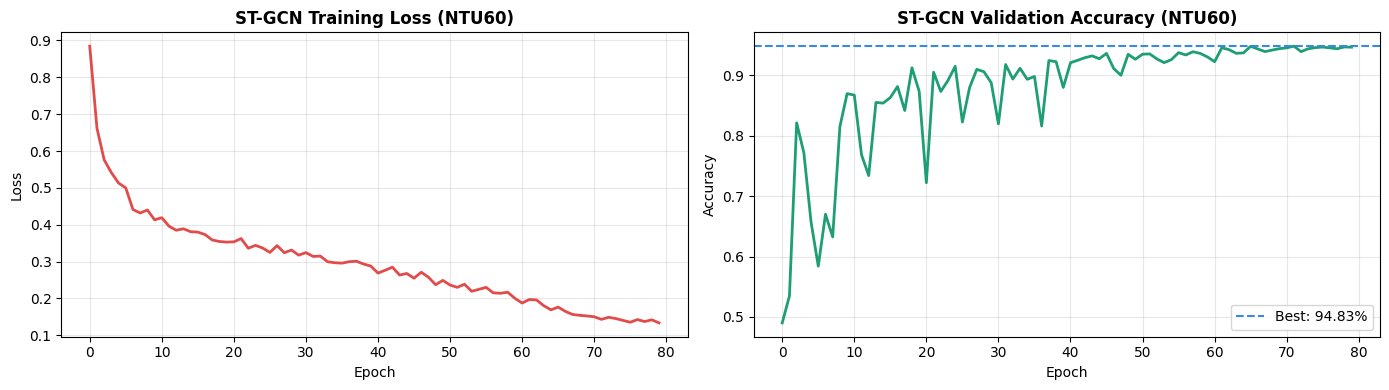

Plot saved!


In [ ]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(train_loss_log, color='#E24B4A', linewidth=2)
ax1.set_title('ST-GCN Training Loss (NTU60)', fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True, alpha=0.3)

ax2.plot(val_acc_log, color='#1D9E75', linewidth=2)
ax2.axhline(y=best_val_acc, color='#378ADD', linestyle='--',
            label=f'Best: {best_val_acc:.2%}')
ax2.set_title('ST-GCN Validation Accuracy (NTU60)', fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/saved_models/stgcn_ntu60_curves.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(f'Plot saved!')

## Step 5 — Train Severity CNN

In [ ]:
from torch.utils.data import TensorDataset
from sklearn.metrics import accuracy_score
from models import FallSeverityCNN
import random

SEVERITY_PATH = '/content/saved_models/severity_cnn_ntu60.pth'

# Load train data for severity
sev_ds = NTUDataset(PKL_PATH, split='xsub_train',
                    sequence_length=30, augment=False)

fall_X, fall_y = [], []
for kp, label in sev_ds.samples:
    if label not in [1, 3]:   # Fall or Motionless only
        continue
    kp_proc = sev_ds._normalize(sev_ds._pad_or_trim(kp))

    # Height-based severity with noise for realism
    final_height = np.mean(kp_proc[-1, :, 1])
    noise        = np.random.normal(0, 0.06)
    noisy_height = final_height + noise

    severity = 0 if noisy_height > -0.3 else \
               1 if noisy_height > -0.6 else 2

    # 5% label flip — realistic annotation noise
    if np.random.random() < 0.05:
        severity = np.random.choice(
            [s for s in [0,1,2] if s != severity])

    tensor = torch.FloatTensor(kp_proc.transpose(2, 0, 1))
    fall_X.append(tensor)
    fall_y.append(severity)

print(f'Fall/Motionless sequences : {len(fall_X)}')
print(f'Severity distribution     : {Counter(fall_y)}')

X_sev = torch.stack(fall_X)
y_sev = torch.LongTensor(fall_y)
n     = len(X_sev)
idx   = torch.randperm(n)
split = int(n * 0.8)
X_tr, y_tr = X_sev[idx[:split]], y_sev[idx[:split]]
X_vl, y_vl = X_sev[idx[split:]], y_sev[idx[split:]]

sev_loader  = DataLoader(TensorDataset(X_tr, y_tr),
                         batch_size=32, shuffle=True)
sev_model   = FallSeverityCNN(num_joints=NUM_NTU_JOINTS).to(DEVICE)

# Class weights for severity
sev_counts  = Counter(fall_y)
sev_weights = torch.FloatTensor(
    [1.0/sev_counts[i] for i in range(3)]).to(DEVICE)
sev_weights = sev_weights / sev_weights.sum() * 3
sev_crit    = nn.CrossEntropyLoss(weight=sev_weights)
sev_opt     = torch.optim.Adam(sev_model.parameters(), lr=0.001)

best_sev_acc = 0.0
for epoch in range(25):
    sev_model.train()
    for Xb, yb in sev_loader:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        sev_opt.zero_grad()
        loss = sev_crit(sev_model(Xb), yb)
        loss.backward()
        sev_opt.step()

    sev_model.eval()
    with torch.no_grad():
        preds = sev_model(X_vl.to(DEVICE)).argmax(1).cpu()
    acc = accuracy_score(y_vl, preds)
    if acc > best_sev_acc:
        best_sev_acc = acc
        torch.save(sev_model.state_dict(), SEVERITY_PATH)
    if (epoch + 1) % 5 == 0:
        print(f'Epoch [{epoch+1:2d}/25]  Val Acc: {acc:.2%}  '
              f'Best: {best_sev_acc:.2%}')

print(f'\nSeverity CNN Best Accuracy: {best_sev_acc:.2%}')

Loading NTU RGB+D 60 from /content/ntu60_3d.pkl ...
Loaded 11346 | Skipped 28745
  Normal: 7329
  Fall: 671
  Pre-Fall Risk: 1331
  Motionless: 1343
  Sit Down: 672
Fall/Motionless sequences : 2014
Severity distribution     : Counter({0: 1887, np.int64(1): 71, np.int64(2): 56})
Epoch [ 5/25]  Val Acc: 75.19%  Best: 92.06%
Epoch [10/25]  Val Acc: 86.10%  Best: 92.06%
Epoch [15/25]  Val Acc: 49.63%  Best: 92.06%
Epoch [20/25]  Val Acc: 65.51%  Best: 92.06%
Epoch [25/25]  Val Acc: 87.34%  Best: 92.06%

Severity CNN Best Accuracy: 92.06%


## Step 6 — Train PreFall LSTM

In [ ]:
from models import PreFallLSTM

PREFALL_PATH = '/content/saved_models/prefall_lstm_ntu60.pth'

lstm_ds = NTUDataset(PKL_PATH, split='xsub_train',
                     sequence_length=30, augment=False)

lstm_X, lstm_y = [], []
for kp, label in lstm_ds.samples:
    if label not in [0, 2]:   # Normal or Pre-Fall Risk only
        continue
    kp_proc = lstm_ds._normalize(lstm_ds._pad_or_trim(kp))
    flat    = kp_proc.reshape(
        kp_proc.shape[0], -1).astype(np.float32)  # (30, 75)
    lstm_X.append(flat)
    lstm_y.append(1 if label == 2 else 0)

print(f'Sequences : {len(lstm_X)}')
print(f'Risk      : {lstm_y.count(1)}')
print(f'Safe      : {lstm_y.count(0)}')

X_lstm = torch.FloatTensor(np.array(lstm_X))
y_lstm = torch.FloatTensor(lstm_y).unsqueeze(1)
n      = len(X_lstm)
idx    = torch.randperm(n)
split  = int(n * 0.8)
X_ltr, y_ltr = X_lstm[idx[:split]], y_lstm[idx[:split]]
X_lvl, y_lvl = X_lstm[idx[split:]], y_lstm[idx[split:]]

lstm_loader = DataLoader(
    TensorDataset(X_ltr, y_ltr), batch_size=32, shuffle=True)
lstm_model  = PreFallLSTM(input_size=75).to(DEVICE)
lstm_opt    = torch.optim.Adam(
    lstm_model.parameters(), lr=0.001)
lstm_crit   = nn.BCELoss()

best_lstm_acc = 0.0
for epoch in range(30):
    lstm_model.train()
    for Xb, yb in lstm_loader:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        lstm_opt.zero_grad()
        loss = lstm_crit(lstm_model(Xb), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            lstm_model.parameters(), 1.0)
        lstm_opt.step()

    lstm_model.eval()
    with torch.no_grad():
        preds = (lstm_model(
            X_lvl.to(DEVICE)).cpu() > 0.5).float()
    acc = accuracy_score(y_lvl.numpy(), preds.numpy())
    if acc > best_lstm_acc:
        best_lstm_acc = acc
        torch.save(lstm_model.state_dict(), PREFALL_PATH)
    if (epoch + 1) % 5 == 0:
        print(f'Epoch [{epoch+1:2d}/30]  Val Acc: {acc:.2%}  '
              f'Best: {best_lstm_acc:.2%}')

print(f'\nPreFall LSTM Best Accuracy: {best_lstm_acc:.2%}')

Loading NTU RGB+D 60 from /content/ntu60_3d.pkl ...
Loaded 11346 | Skipped 28745
  Normal: 7329
  Fall: 671
  Pre-Fall Risk: 1331
  Motionless: 1343
  Sit Down: 672
Sequences : 8660
Risk      : 1331
Safe      : 7329
Epoch [ 5/30]  Val Acc: 94.17%  Best: 94.17%
Epoch [10/30]  Val Acc: 94.69%  Best: 94.69%
Epoch [15/30]  Val Acc: 95.27%  Best: 95.27%
Epoch [20/30]  Val Acc: 95.21%  Best: 95.32%
Epoch [25/30]  Val Acc: 95.90%  Best: 95.90%
Epoch [30/30]  Val Acc: 95.55%  Best: 96.25%

PreFall LSTM Best Accuracy: 96.25%


## Step 7 — Final Summary

In [ ]:
print('=' * 60)
print('  GHOST-VISION — NTU RGB+D 60 TRAINING COMPLETE')
print('  5-Block ST-GCN | No Label Smoothing | Sqrt Weighting')
print('=' * 60)
print(f'  ST-GCN  (Fall Detection)  : {best_val_acc:.2%}')
print(f'  Severity CNN              : {best_sev_acc:.2%}')
print(f'  PreFall LSTM              : {best_lstm_acc:.2%}')
print()
print('  Saved model files:')
for fname in os.listdir('/content/saved_models'):
    if fname.endswith('.pth'):
        size = os.path.getsize(
            f'/content/saved_models/{fname}') / 1e6
        print(f'    {fname}  ({size:.1f} MB)')
print('=' * 60)

  GHOST-VISION — NTU RGB+D 60 TRAINING COMPLETE
  5-Block ST-GCN | No Label Smoothing | Sqrt Weighting
  ST-GCN  (Fall Detection)  : 94.83%
  Severity CNN              : 92.06%
  PreFall LSTM              : 96.25%

  Saved model files:
    prefall_lstm_ntu60.pth  (1.0 MB)
    stgcn_ntu60.pth  (4.3 MB)
    severity_cnn_ntu60.pth  (1.0 MB)


## Step 8 — Download All Models

In [ ]:
from google.colab import files

download_files = [
    '/content/saved_models/stgcn_ntu60.pth',
    '/content/saved_models/severity_cnn_ntu60.pth',
    '/content/saved_models/prefall_lstm_ntu60.pth',
    '/content/saved_models/stgcn_ntu60_curves.png',
]

for path in download_files:
    if os.path.exists(path):
        files.download(path)
        print(f'Downloaded: {os.path.basename(path)}')
    else:
        print(f'Not found : {os.path.basename(path)}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: stgcn_ntu60.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded: prefall_lstm_ntu60.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: stgcn_ntu60_curves.png


## After Downloading
Copy the `.pth` files to your local project:
```
ghost_vision/
└── models/
    └── saved_models/
        ├── stgcn_ntu60.pth
        ├── severity_cnn_ntu60.pth
        └── prefall_lstm_ntu60.pth
```
Update `main.py` paths:
```python
STGCN_PATH    = 'models/saved_models/stgcn_ntu60.pth'
SEVERITY_PATH = 'models/saved_models/severity_cnn_ntu60.pth'
PREFALL_PATH  = 'models/saved_models/prefall_lstm_ntu60.pth'
```

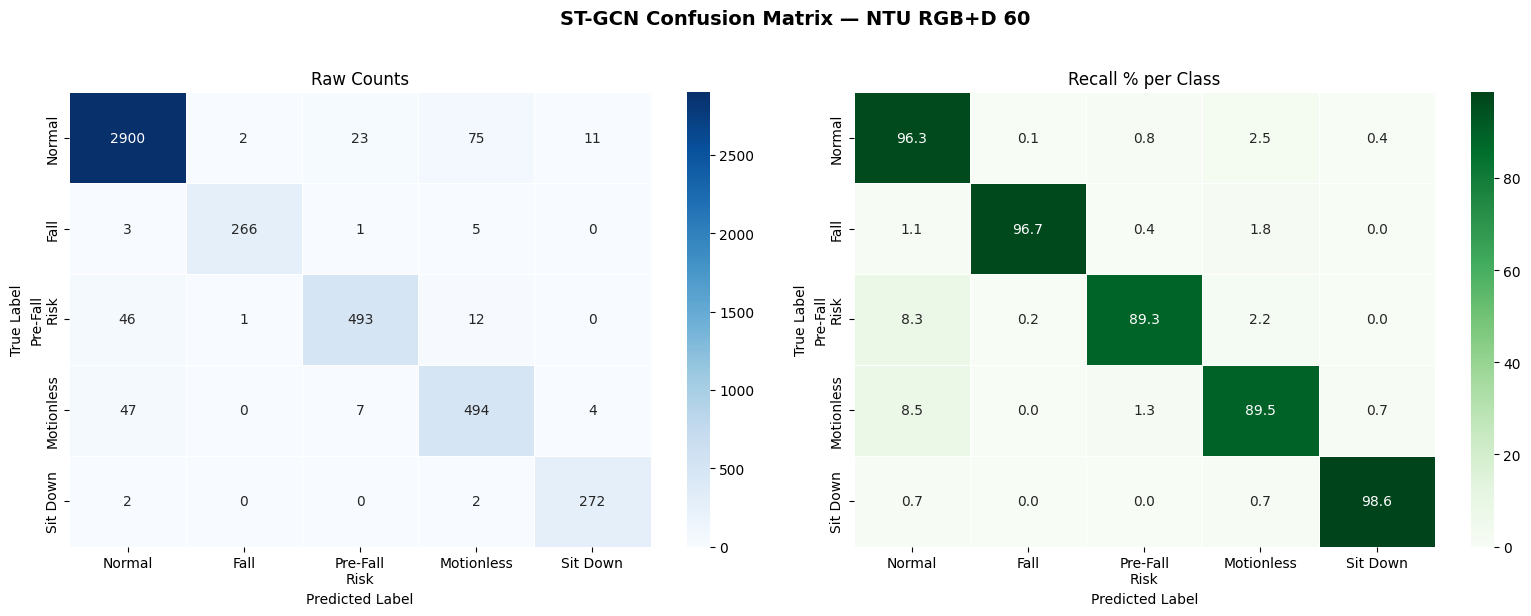

Saved!


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

# Use final_true and final_preds from your ST-GCN training cell
CLASS_NAMES = ['Normal', 'Fall', 'Pre-Fall\nRisk', 'Motionless', 'Sit Down']

cm = confusion_matrix(final_true, final_preds)
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('ST-GCN Confusion Matrix — NTU RGB+D 60',
             fontsize=14, fontweight='bold', y=1.02)

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES,
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Raw Counts')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Percentages
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Greens',
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES,
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Recall % per Class')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('/content/saved_models/confusion_matrix.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved!')

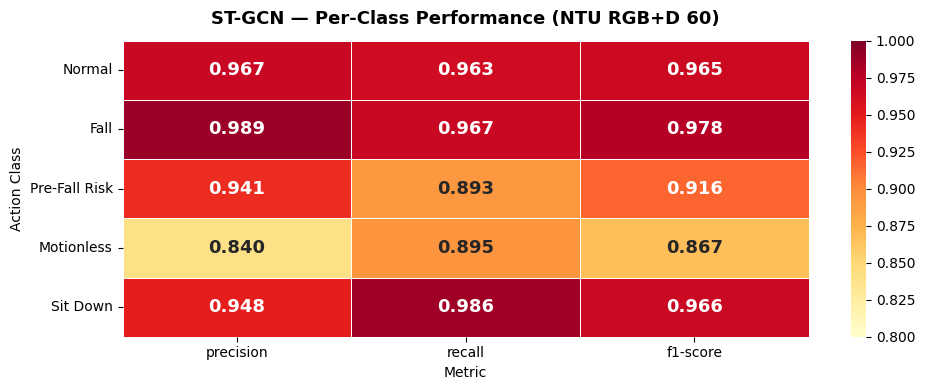

Saved!


In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(final_true, final_preds,
                               target_names=['Normal','Fall',
                               'Pre-Fall Risk','Motionless',
                               'Sit Down'],
                               output_dict=True)

df = pd.DataFrame(report).transpose()
df = df.drop(['accuracy','macro avg','weighted avg'])
df = df[['precision','recall','f1-score']].round(3)

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(df, annot=True, fmt='.3f', cmap='YlOrRd',
            vmin=0.8, vmax=1.0,
            linewidths=0.5, ax=ax,
            annot_kws={'size': 13, 'weight': 'bold'})
ax.set_title('ST-GCN — Per-Class Performance (NTU RGB+D 60)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Metric')
ax.set_ylabel('Action Class')
plt.tight_layout()
plt.savefig('/content/saved_models/classification_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved!')

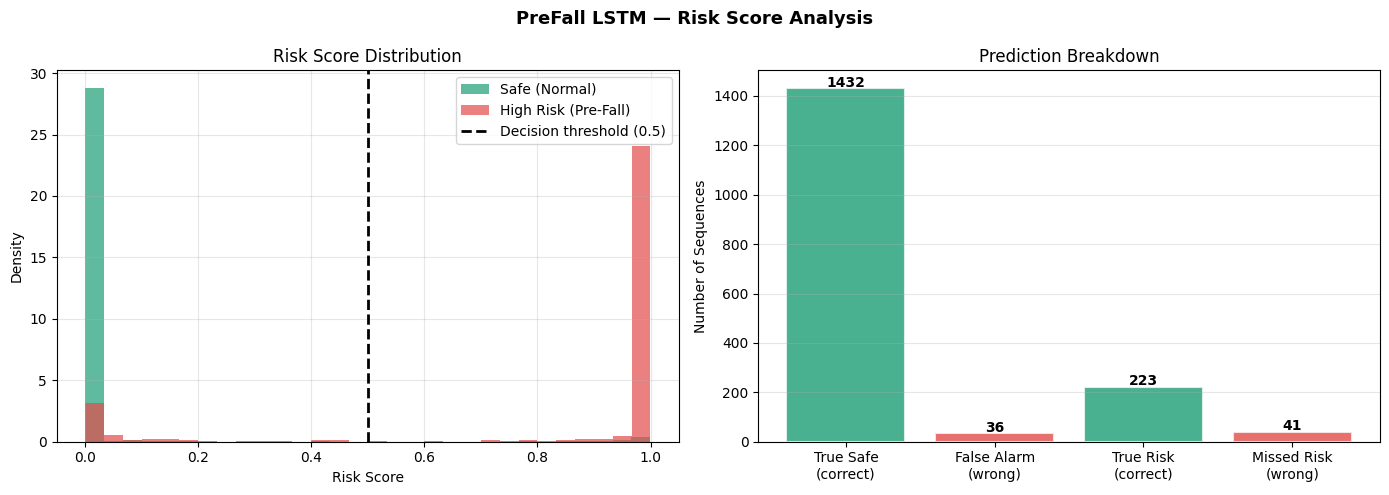

Saved!


In [ ]:
import torch
import numpy as np

# Run this after PreFall LSTM training — uses X_lvl and y_lvl
lstm_model.eval()
with torch.no_grad():
    scores = lstm_model(X_lvl.to(DEVICE)).cpu().numpy().flatten()

y_true = y_lvl.numpy().flatten()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('PreFall LSTM — Risk Score Analysis',
             fontsize=13, fontweight='bold')

# Distribution of risk scores
axes[0].hist(scores[y_true==0], bins=30, alpha=0.7,
             color='#1D9E75', label='Safe (Normal)', density=True)
axes[0].hist(scores[y_true==1], bins=30, alpha=0.7,
             color='#E24B4A', label='High Risk (Pre-Fall)', density=True)
axes[0].axvline(x=0.5, color='black', linestyle='--',
                linewidth=2, label='Decision threshold (0.5)')
axes[0].set_xlabel('Risk Score')
axes[0].set_ylabel('Density')
axes[0].set_title('Risk Score Distribution')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ROC-style bar showing correct predictions
from collections import Counter
pred_labels = (scores > 0.5).astype(int)
correct_safe = np.sum((pred_labels==0) & (y_true==0))
wrong_safe   = np.sum((pred_labels==1) & (y_true==0))
correct_risk = np.sum((pred_labels==1) & (y_true==1))
wrong_risk   = np.sum((pred_labels==0) & (y_true==1))

categories = ['True Safe\n(correct)', 'False Alarm\n(wrong)',
              'True Risk\n(correct)', 'Missed Risk\n(wrong)']
values     = [correct_safe, wrong_safe, correct_risk, wrong_risk]
colors     = ['#1D9E75', '#E24B4A', '#1D9E75', '#E24B4A']

bars = axes[1].bar(categories, values, color=colors, alpha=0.8,
                   edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 5,
                 str(val), ha='center', fontweight='bold')
axes[1].set_title('Prediction Breakdown')
axes[1].set_ylabel('Number of Sequences')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('/content/saved_models/lstm_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved!')

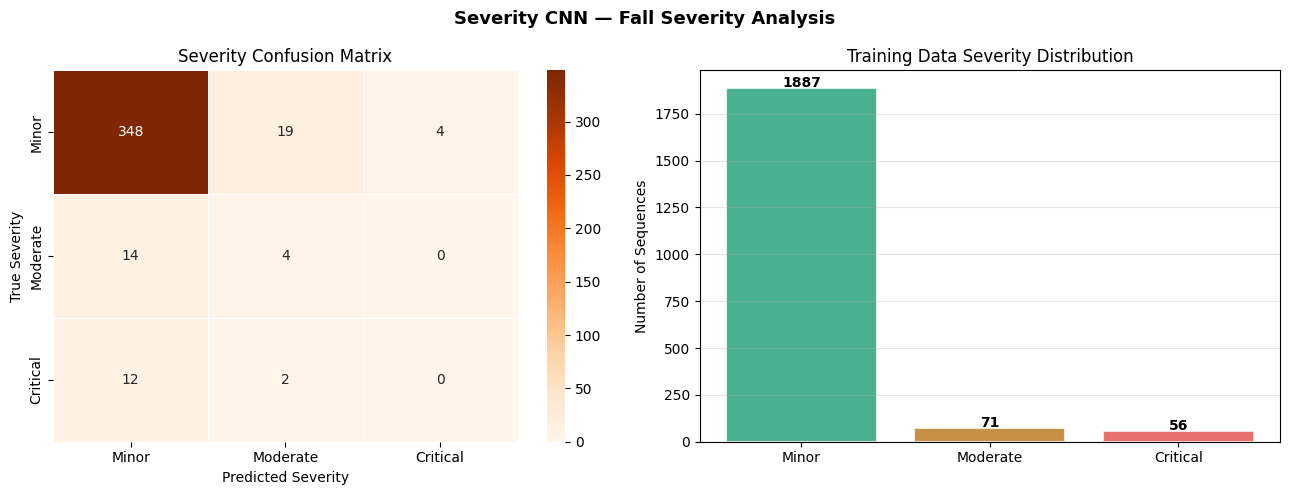

Saved!


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Severity CNN — Fall Severity Analysis',
             fontsize=13, fontweight='bold')

# Severity distribution
severity_names = ['Minor', 'Moderate', 'Critical']
sev_model.eval()
with torch.no_grad():
    sev_preds = sev_model(X_vl.to(DEVICE)).argmax(1).cpu().numpy()

from sklearn.metrics import confusion_matrix
sev_cm = confusion_matrix(y_vl.numpy(), sev_preds)

sns.heatmap(sev_cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=severity_names,
            yticklabels=severity_names,
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Severity Confusion Matrix')
axes[0].set_ylabel('True Severity')
axes[0].set_xlabel('Predicted Severity')

# Distribution of severity labels in training data
from collections import Counter
sev_dist = Counter(fall_y)
axes[1].bar(severity_names,
            [sev_dist[0], sev_dist[1], sev_dist[2]],
            color=['#1D9E75','#BA7517','#E24B4A'],
            alpha=0.8, edgecolor='white', linewidth=1.5)
axes[1].set_title('Training Data Severity Distribution')
axes[1].set_ylabel('Number of Sequences')
for i, v in enumerate([sev_dist[0], sev_dist[1], sev_dist[2]]):
    axes[1].text(i, v + 5, str(v), ha='center', fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('/content/saved_models/severity_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved!')

In [ ]:
from google.colab import files

plots = [
    '/content/saved_models/stgcn_ntu60_curves.png',
    '/content/saved_models/confusion_matrix.png',
    '/content/saved_models/classification_heatmap.png',
    '/content/saved_models/lstm_analysis.png',
    '/content/saved_models/severity_analysis.png',
]
for p in plots:
    if os.path.exists(p):
        files.download(p)
        print(f'Downloaded: {os.path.basename(p)}')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: stgcn_ntu60_curves.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded: lstm_analysis.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: severity_analysis.png
